In [5]:
import os
import pandas as pd
import matplotlib.pyplot as plt

# Make sure an images folder exists next to docs/
os.makedirs("../docs/images", exist_ok=True)

# Load all runs
df = pd.read_csv("../results.csv")
df


,timestamp_logged,job_name,region,start_time,est_end_time,avg_carbon_intensity,baseline_carbon,actual_carbon,savings_pct
0,2025-11-17T22:30:53.635687,resnet_cifar10,eu-north,2025-11-17T22:30:53.391644,2025-11-18T00:30:53.391644,150.0,900.0,300.0,66.67


In [6]:
df[["job_name", "region", "avg_carbon_intensity", "baseline_carbon", "actual_carbon", "savings_pct"]]


,job_name,region,avg_carbon_intensity,baseline_carbon,actual_carbon,savings_pct
0,resnet_cifar10,eu-north,150.0,900.0,300.0,66.67


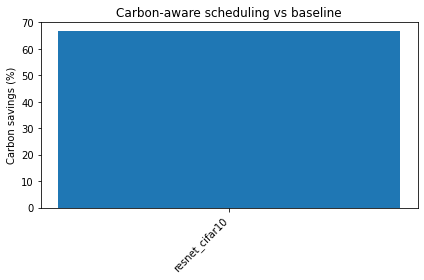

In [7]:
# Plot carbon savings (%) per run and save as PNG
fig, ax = plt.subplots()

ax.bar(range(len(df)), df["savings_pct"])
ax.set_xticks(range(len(df)))
ax.set_xticklabels(df["job_name"], rotation=45, ha="right")
ax.set_ylabel("Carbon savings (%)")
ax.set_title("Carbon-aware scheduling vs baseline")

fig.tight_layout()

# 👇 Save the figure as a PNG
fig.savefig("../docs/images/savings_pct.png", dpi=300, bbox_inches="tight")

plt.show()


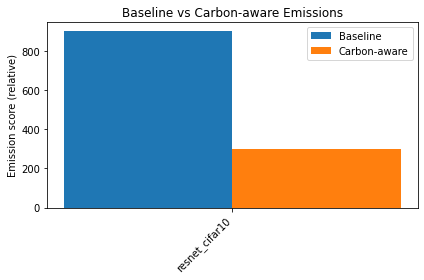

In [8]:
# Plot baseline vs carbon-aware emission scores and save as PNG
fig, ax = plt.subplots()

width = 0.35
indices = range(len(df))

ax.bar([i - width/2 for i in indices], df["baseline_carbon"], 
       width, label="Baseline")
ax.bar([i + width/2 for i in indices], df["actual_carbon"], 
       width, label="Carbon-aware")

ax.set_xticks(list(indices))
ax.set_xticklabels(df["job_name"], rotation=45, ha="right")
ax.set_ylabel("Emission score (relative)")
ax.set_title("Baseline vs Carbon-aware Emissions")
ax.legend()

fig.tight_layout()

# 👇 Save the figure as a PNG
fig.savefig("../docs/images/baseline_vs_carbonaware.png", dpi=300, bbox_inches="tight")

plt.show()
